# Notebook : Analyse du contenu audiovisuel proposé par Netflix

---
<img src="https://asset.brandfetch.io/idvDrMBg3m/idgDR62lX4.png" alt="Logo Data Rockstars" width="274" height="80">

### 🔒 Le contenu de ce document est confidentiel. 📝
_Le contenu de ce document est confidentiel et la copie ou la distribution est interdite._ 😶‍🌫️

📧 Pour toute question, veuillez nous contacter à [contact@datarockstars.ai](mailto:contact@datarockstars.ai)

---
# Le programme du notebook

**📖 Au programme**
- Manipulation de Pandas
- Data Visualisation (Matplotlib, Seaborn, Bokeh, Plotly)

**🎁 Les takeaways**
- Slides de cours
- Accès à la plateforme
- Notebooks
- Snippets penses bêtes de code que vous pouvez garder à vie

---

# Motivation
Dans un monde de plus en plus numérique, les plateformes de streaming comme Netflix jouent un rôle majeur dans la manière dont nous consommons les médias. Avec une variété quasi infinie de contenus disponibles, il est essentiel de comprendre comment ces contenus sont distribués, quels types de programmes sont les plus courants, et quelles tendances émergent de ces données.

**Conseil : N'hésitez pas à explorer au maximum les données et d'aller au-delà des questions formulées. La pratique est essentielle pour renforcer vos compétences en analyse de données. Évitez également de regarder les indices trop facilement.**

---


<div style="border:2px solid red; padding: 10px;">
    <p style="color: red;"><strong>⚠️ Soumettre votre challenge à la fin de chaque module ⚠️</strong></p>
    <ul>
        <li>💾 Avant de soumettre le lab, pensez à bien <strong> télécharger votre Jupyter notebook</strong> en cliquant sur <em>Fichier > Download.</em>.</li>
        <li>✏️ Seul le notebook <code>main.ipynb</code> sera sauvegardé et envoyé pour évaluation à vos professeurs. Si vous avez d'autres notebooks, ils ne seront <strong>pas comptabilisés. </strong></li>
        <li>🚫 Une fois que vous avez soumis votre travail, vous ne pourrez plus le modifier. Vous aurez cependant, la possibilité de faire une nouvelle tentative autant de fois que souhaité.</li>
    </ul>
    <p>Assurez-vous de vérifier vos fichiers avant de procéder !</p>
</div>

# Imports et initialisation

### Question 1

❓**Question 1 :** Commencez par importer les bibliothèques nécessaires pour traiter et analyser les données. Nous aurons besoin des bibliothèques suivantes : pandas, numpy, matplotlib, seaborn, plotly.

In [59]:
!pip3 install seaborn bokeh

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


<details>
  <summary>
    Indice 🔑
  </summary>

Si vous ne parvenez pas à importer une bibliothèque, il est possible qu'elle ne soit pas installée sur le kernel. Vous serez alors susceptible d'avoir besoin de la commande "pip install".
</details>

### Question 2

❓**Question 2 :** Chargez la base de données pré-chargée contenue dans le fichier netflix_titles.csv en utilisant la bibliothèque Pandas. Affichez ensuite les 10 premières et 10 dernières lignes du dataframe pour avoir un aperçu des données.

Quelles observations pouvez-vous faire sur la structure des données ? Quels types de variables sont présentes ?

In [6]:
df = pd.read_csv("netflix_titles.csv")  # Remplace par le chemin réel
print(df.head())  # Affiche les premières lignes

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons   
1  December 23, 2016          2016  TV-MA     93 min   
2  December 20, 2018          2011      R     78 min   
3  November 16, 2017          2009  PG-13     80 min   
4   

<details>
  <summary>
    Indice 🔑
  </summary>
  Utilisez la fonction `read_csv()` de pandas pour charger le fichier et la méthode `head()` pour afficher les premières lignes.
</details>


# Data Cleaning

🎯 **Objectif :** Une étape cruciale dans la préparation des données pour l'analyse est de comprendre où se trouvent les lacunes ou les données manquantes. Ceci est important car la présence de données manquantes peut influencer les résultats de notre analyse.


### Question 3

❓**Question 3 :** Écrivez un code qui parcourt toutes les colonnes du dataframe df et affiche le pourcentage de données manquantes pour chaque colonne qui contient au moins une donnée manquante.

In [7]:
total_lignes = len(df)

for colonne in df.columns:
    nb_nan = df[colonne].isna().sum()
    if nb_nan > 0:
        pourcentage = (nb_nan / total_lignes) * 100
        print(f"Colonne '{colonne}' : {pourcentage:.2f}% de données manquantes")

Colonne 'director' : 30.68% de données manquantes
Colonne 'cast' : 9.22% de données manquantes
Colonne 'country' : 6.51% de données manquantes
Colonne 'date_added' : 0.13% de données manquantes
Colonne 'rating' : 0.09% de données manquantes


<details>
  <summary>
    Indice 🔑
  </summary>
  Utilisez une boucle `for` pour parcourir les colonnes et la méthode `isna()` pour identifier les données manquantes.
</details>


### Question 4

❓**Question 4 :** Nettoyez le DataFrame df.

In [8]:
df['director'] = df['director'].fillna('Various')
df['cast'] = df['cast'].fillna('Not specified')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

df['type'] = df['type'].replace({'TV Show': 'TV', 'Movie': 'Film'})

df = df.dropna()
df = df.drop_duplicates()

<details>
  <summary>
    Indice 🔑
  </summary>
  - Utilisez la méthode `fillna()` pour remplacer les données manquantes.
  - Utilisez la méthode `replace()` pour remplacer des valeurs spécifiques.
  - Utilisez la méthode `dropna()` pour supprimer les lignes avec des données manquantes.
  - Utilisez la méthode `drop_duplicates()` pour supprimer les doublons.
</details>

### Question 5

🎯 **Objectif :** La gestion correcte des dates est essentielle dans la plupart des analyses de données. Cela nous permet de réaliser des analyses temporelles, de comprendre des tendances et d'obtenir des informations saisonnières.

❓**Question 5 :** Procédez aux transformations suivantes sur le DataFrame df :

- Convertissez la colonne date_added au format datetime.
- Créez une nouvelle colonne month_added qui contiendra le mois (sous forme de numéro) auquel chaque titre a été ajouté.
- Créez une nouvelle colonne month_name_added qui contiendra le nom du mois auquel chaque titre a été ajouté.
- Créez une nouvelle colonne year_added qui contiendra l'année d'ajout de chaque titre.
- Enfin, affichez les 3 premières lignes du dataframe pour vérifier vos transformations.

In [9]:
# 1. Conversion de la colonne date_added au format datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 2. Création de la colonne month_added (mois en numéro)
df['month_added'] = df['date_added'].dt.month

# 3. Création de la colonne month_name_added (nom du mois)
df['month_name_added'] = df['date_added'].dt.month_name()

# 4. Création de la colonne year_added (année)
df['year_added'] = df['date_added'].dt.year

# 5. Affichage des 3 premières lignes pour vérification
print(df[['date_added', 'month_added', 'month_name_added', 'year_added']].head(3))


  date_added  month_added month_name_added  year_added
0 2020-08-14          8.0           August      2020.0
1 2016-12-23         12.0         December      2016.0
2 2018-12-20         12.0         December      2018.0


<details>
  <summary>
    Indice 🔑
  </summary>
  Utilisez la fonction `to_datetime()` pour convertir la colonne en datetime et les attributs `.dt.month`, `.dt.month_name()`, et `.dt.year` pour extraire les composantes des dates.
</details>


# Data Visualisation

### Question 6

❓**Question 6 :** À l'aide de Pandas, récupérez :

- Le premier film ou la première série ajouté(e) au dataset
- Le dernier film ou la dernière série ajouté(e) au dataset
- La description du film "Puss in boots"
- La liste des films réalisés par "Alfred Hitchcock"
- Le nombre de films sortis en 2018

In [10]:
import pandas as pd

In [11]:
premier = df.sort_values('date_added').iloc[0]
print("Premier titre ajouté :")
print(premier[['title', 'date_added']])


Premier titre ajouté :
title         To and From New York
date_added     2008-01-01 00:00:00
Name: 7113, dtype: object


In [12]:
dernier = df.sort_values('date_added', ascending=False).iloc[0]
print("Dernier titre ajouté :")
print(dernier[['title', 'date_added']])


Dernier titre ajouté :
title                Radium Girls
date_added    2021-01-16 00:00:00
Name: 5059, dtype: object


In [11]:
desc_puss = df[df['title'].str.lower() == 'puss in boots'.lower()]['description']
print("Description de 'Puss in Boots' :")
print(desc_puss.values[0] if not desc_puss.empty else "Non trouvé")


Description de 'Puss in Boots' :
The fabled feline heads to the Land of Giants with friends Humpty Dumpty and Kitty Softpaws on a quest to nab its greatest treasure: the Golden Goose.


In [13]:
hitchcock_films = df[df['director'] == 'Alfred Hitchcock']
print("Films réalisés par Alfred Hitchcock :")
print(hitchcock_films[['title', 'type', 'release_year']])


Films réalisés par Alfred Hitchcock :
Empty DataFrame
Columns: [title, type, release_year]
Index: []


In [14]:
nb_films_2018 = df[(df['release_year'] == 2018) & (df['type'] == 'Film')].shape[0]
print(f"Nombre de films sortis en 2018 : {nb_films_2018}")


Nombre de films sortis en 2018 : 734


### Question 7

❓**Question 7 :** Quels sont les trois genres les plus communs sur Netflix ? Visualisez la répartition de ces genres dans un diagramme en barres.

**Conseil :** Utilisez la fonction `bar()` de Matplotlib pour tracer un diagramme en barres. N'oubliez pas de définir des labels pour les axes, un titre pour le graphique, et éventuellement une légende si nécessaire.

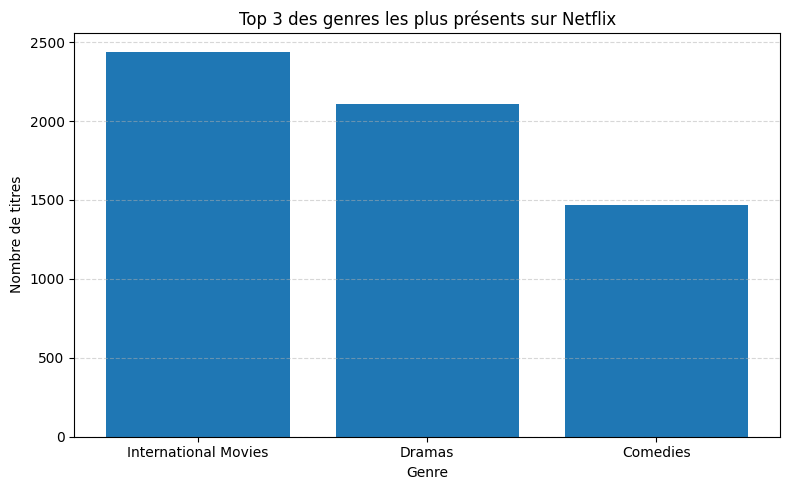

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. On crée une liste de tous les genres (séparés par virgule)
genres_series = df['listed_in'].dropna().str.split(', ')
all_genres = [genre for sublist in genres_series for genre in sublist]

# 2. On compte leur fréquence
genre_counts = Counter(all_genres)

# 3. On récupère les 3 genres les plus fréquents
top_genres = genre_counts.most_common(3)
genres, counts = zip(*top_genres)

# 4. Visualisation avec Matplotlib
plt.figure(figsize=(8,5))
plt.bar(genres, counts)
plt.title("Top 3 des genres les plus présents sur Netflix")
plt.xlabel("Genre")
plt.ylabel("Nombre de titres")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Question 8

❓**Question 8 :** Calculez le ratio de chaque type (Movies et TV Shows) par rapport au total des entrées dans le DataFrame. Stocker ces ratios dans une liste de deux éléments : ['ratio de films', 'ratio de séries']. À l'aide de Matplotlib, tracez un diagramme en barres permettant de visualiser cet écart de ratio.

Ratios : [0.6905098240657506, 0.3094901759342494]


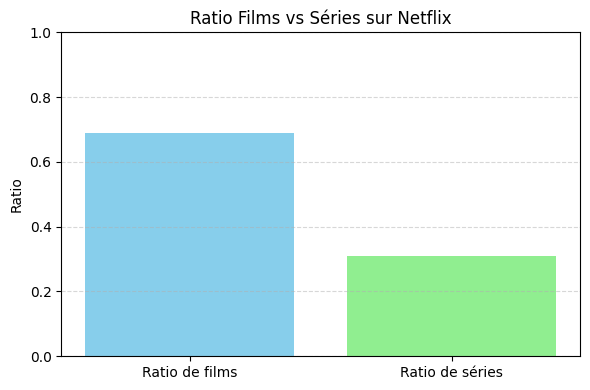

In [16]:
import matplotlib.pyplot as plt

# 1. Comptage des types
type_counts = df['type'].value_counts()
total = len(df)

# 2. Calcul des ratios
ratio_film = type_counts.get('Film', 0) / total
ratio_tv = type_counts.get('TV', 0) / total

# 3. Stocker dans une liste
ratios = [ratio_film, ratio_tv]
labels = ['Ratio de films', 'Ratio de séries']

print(f"Ratios : {ratios}")

# 4. Diagramme en barres
plt.figure(figsize=(6,4))
plt.bar(labels, ratios, color=['skyblue', 'lightgreen'])
plt.ylim(0,1)
plt.title("Ratio Films vs Séries sur Netflix")
plt.ylabel("Ratio")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

❓**Question 8.1 :** Comment la quantité de contenu (Movies et TV Shows) a-t-elle évolué sur Netflix d'année en année ? Créez un graphique linéaire pour visualiser cette tendance.

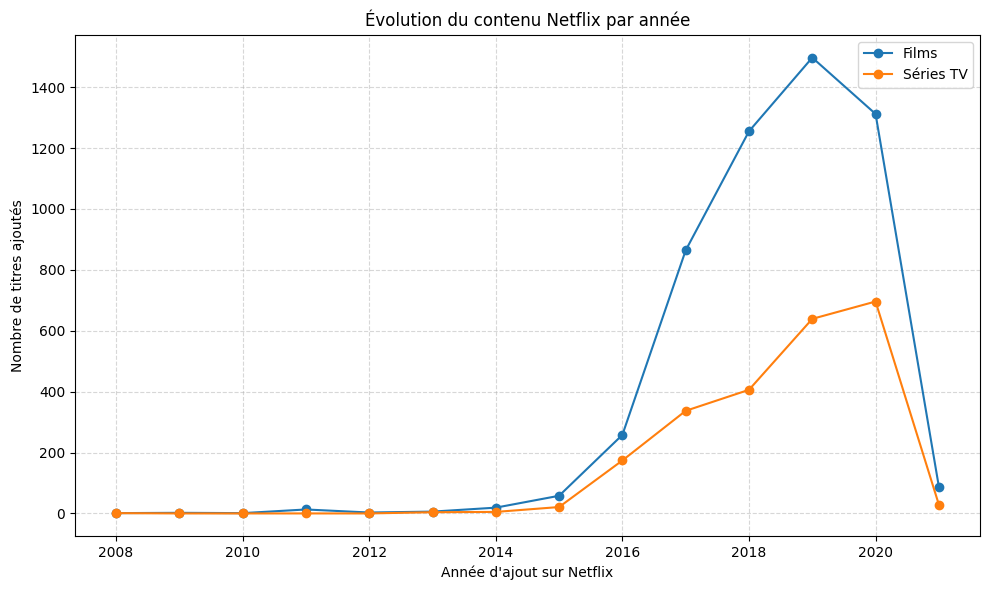

In [17]:
df['year_added'] = pd.to_numeric(df['year_added'], errors='coerce')

# 2. Grouper par année et type
yearly_counts = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# 3. Tracer un graphique linéaire
plt.figure(figsize=(10,6))
plt.plot(yearly_counts.index, yearly_counts['Film'], label='Films', marker='o')
plt.plot(yearly_counts.index, yearly_counts['TV'], label='Séries TV', marker='o')

plt.title("Évolution du contenu Netflix par année")
plt.xlabel("Année d'ajout sur Netflix")
plt.ylabel("Nombre de titres ajoutés")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

❓**Question 8.2 :** Comment le ratio de chaque type (Movies et TV Shows) a-t-il évolué sur Netflix d'année en année ? Superposer un nouvelle courbe avec celle du graphique précédent.

**Conseil :** N'oubliez pas d'ajouter une deuxième échelle et des graduations pour rendre le graphique plus lisible.

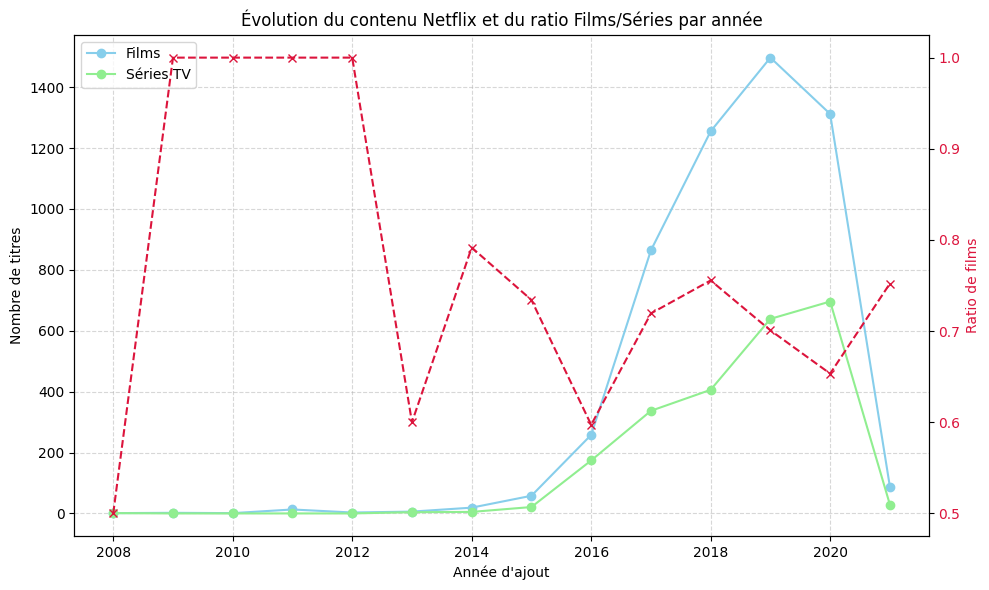

In [18]:
year_type_counts = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# 2. Calcul du total par an
year_type_counts['Total'] = year_type_counts.sum(axis=1)

# 3. Calcul du ratio de films
year_type_counts['Ratio_Film'] = year_type_counts['Film'] / year_type_counts['Total']
# (Ratio TV serait : 1 - Ratio_Film)

# 4. Création du graphique
fig, ax1 = plt.subplots(figsize=(10,6))

# Axe principal : nombre de titres
ax1.plot(year_type_counts.index, year_type_counts['Film'], label='Films', color='skyblue', marker='o')
ax1.plot(year_type_counts.index, year_type_counts['TV'], label='Séries TV', color='lightgreen', marker='o')
ax1.set_xlabel('Année d\'ajout')
ax1.set_ylabel('Nombre de titres')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Axe secondaire : ratio de films
ax2 = ax1.twinx()
ax2.plot(year_type_counts.index, year_type_counts['Ratio_Film'], color='crimson', label='Ratio de films', linestyle='--', marker='x')
ax2.set_ylabel('Ratio de films', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Affichage
plt.title("Évolution du contenu Netflix et du ratio Films/Séries par année")
fig.tight_layout()
plt.show()

### Question 9

🎯 **Objectif :** Avant de réaliser une analyse plus approfondie, il peut être nécessaire de simplifier les étiquettes et colonnes à partir des données existantes. Ceci est fait pour rendre les données plus exploitables ou pour découvrir de nouvelles perspectives d'analyse.

❓**Question 9 :** Suivez les étapes ci-dessous :

- De nombreuses productions ont plusieurs pays listés. Pour simplifier, créez une nouvelle colonne first_country en ne conservant que le premier pays mentionné.
- À partir du notebook mentionné, on vous fournit un dictionnaire ratings_ages. Utilisez-le pour créer une nouvelle colonne target_ages en remplaçant les notes par les groupes d'âge correspondants.
- Transformez la colonne listed_in pour créer une nouvelle colonne genre contenant les genres sous forme de liste.
- Pour faciliter certaines visualisations, réduisez la longueur de certains noms de pays (par exemple, 'United States' devient 'USA').

In [19]:
ratings_ages = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}

In [29]:
df['first_country'] = df['country'].str.split(',').str[0].str.strip()
df['target_ages'] = df['rating'].map(ratings_ages)
df['genre'] = df['listed_in'].str.split(', ').apply(lambda x: [g.strip() for g in x])
country_short = {
    'United States': 'USA',
    'United Kingdom': 'UK',
    'South Korea': 'S. Korea',
    'Russia': 'RU',
    'Japan': 'JP',
    'Germany': 'DE',
    'France': 'FR',
    'Canada': 'CA',
    'India': 'IN'
}

df['first_country'] = df['first_country'].replace(country_short)
print(df[['country', 'first_country', 'rating', 'target_ages', 'listed_in', 'genre']].head())


         country first_country rating target_ages  \
0         Brazil        Brazil  TV-MA      Adults   
1         Mexico        Mexico  TV-MA      Adults   
2      Singapore     Singapore      R      Adults   
3  United States           USA  PG-13       Teens   
4  United States           USA  PG-13       Teens   

                                           listed_in  \
0  International TV Shows, TV Dramas, TV Sci-Fi &...   
1                       Dramas, International Movies   
2                Horror Movies, International Movies   
3  Action & Adventure, Independent Movies, Sci-Fi...   
4                                             Dramas   

                                               genre  
0  [International TV Shows, TV Dramas, TV Sci-Fi ...  
1                     [Dramas, International Movies]  
2              [Horror Movies, International Movies]  
3  [Action & Adventure, Independent Movies, Sci-F...  
4                                           [Dramas]  


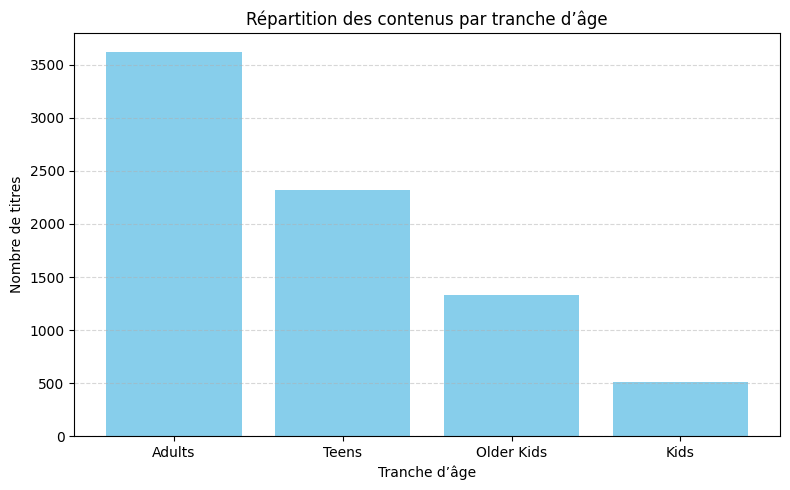

In [30]:
age_counts = df['target_ages'].value_counts()

# Diagramme en barres
plt.figure(figsize=(8,5))
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.title("Répartition des contenus par tranche d’âge")
plt.xlabel("Tranche d’âge")
plt.ylabel("Nombre de titres")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

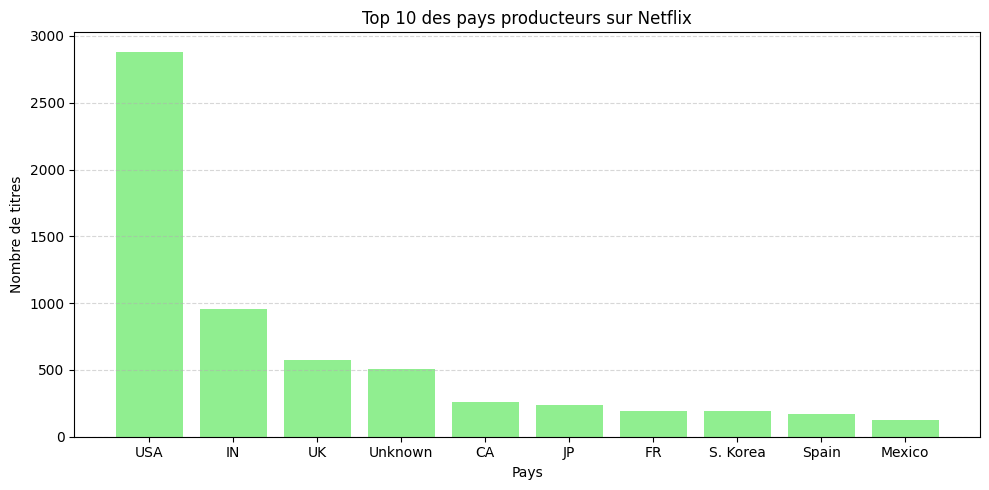

In [31]:
country_counts = df['first_country'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(country_counts.index, country_counts.values, color='lightgreen')
plt.title("Top 10 des pays producteurs sur Netflix")
plt.xlabel("Pays")
plt.ylabel("Nombre de titres")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Question 10

❓**Question 10 :** À l'aide de GeoViz (ou une autre bibliothèque de visualisation géographique de votre choix, comme Plotly ou Folium), affichez une carte sur laquelle :

- Les pays les plus représentés dans le dataset sont coloriés en rouge foncé.
- Les pays moins représentés sont en jaune ou en nuances plus claires de rouge.

In [45]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 29.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.4/373.4 kB 29.6 MB/s eta 0:00:00


In [49]:
import plotly.io as pio
pio.renderers.default = 'notebook'

In [51]:
# 1. Compter les titres par pays
country_counts = df['first_country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

# 2. Créer la carte choroplèthe
fig = px.choropleth(
    country_counts,
    locations='country',
    locationmode='country names',
    color='count',
    color_continuous_scale='YlOrRd',
    title='Nombre de titres Netflix par pays'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False),
    coloraxis_colorbar=dict(title='Nombre de titres')
)

fig.show()


<details>
  <summary>
    Indice 🔑
  </summary>
  Commencez par regrouper les données par pays et comptez le nombre de titres pour chaque pays. Utilisez ces comptages pour colorer les pays sur la carte.
</details>


### Question 11

❓**Question 11 :** En utilisant la bibliothèque Seaborn, créez un diagramme en barre qui illustre les 10 pays avec le plus grand nombre de titres sur Netflix, tout en subdivisant chaque barre pour montrer la distinction entre "Movies" et "TV Shows".

In [52]:
import seaborn as sns

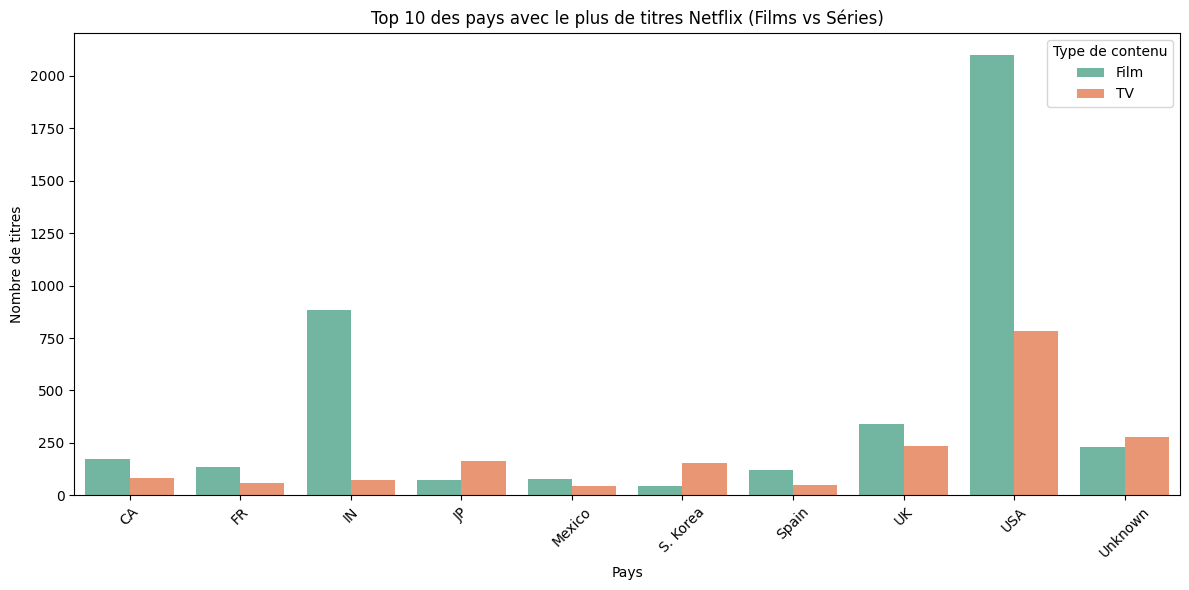

In [53]:
# 1. Grouper par pays et type (Film/TV)
grouped = df.groupby(['first_country', 'type']).size().reset_index(name='count')

# 2. Calculer le total par pays pour trier
totals = grouped.groupby('first_country')['count'].sum().sort_values(ascending=False)

# 3. Sélectionner les 10 premiers pays
top_10_countries = totals.head(10).index

# 4. Filtrer le DataFrame sur ces pays
top_data = grouped[grouped['first_country'].isin(top_10_countries)]

# 5. Tracer avec Seaborn
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_data,
    x='first_country',
    y='count',
    hue='type',
    palette='Set2'
)

plt.title("Top 10 des pays avec le plus de titres Netflix (Films vs Séries)")
plt.xlabel("Pays")
plt.ylabel("Nombre de titres")
plt.legend(title='Type de contenu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<details>
  <summary>
    Indice 🔑
  </summary>
  
  - Préparez vos données en regroupant le dataframe df par pays et par type de contenu, et comptez le nombre de titres pour chaque combinaison.
  - Triez les pays par ordre décroissant en fonction du nombre total de titres.
  - Utilisez Seaborn (fonction barplot()) pour tracer le diagramme en barre des 10 premiers pays avec la distinction entre "Movies" et "TV Shows". Vous pourriez également envisager d'utiliser un hue pour distinguer entre les types de contenu. N'oubliez pas d'ajouter des labels à vos axes et une légende pour une meilleure compréhension du graphique.
</details>

### Question 12

❓ **Question 12 :** En utilisant le dataframe df et les outils de visualisation à votre disposition, créez un diagramme en barres verticales qui illustre la distribution des notations pour les films et les émissions de télévision.

💡 Vous pourriez envisager d'utiliser un diagramme en barres verticales groupé. Le choix de couleurs distinctes pour les films et les émissions de télévision aidera à la clarté de la visualisation.

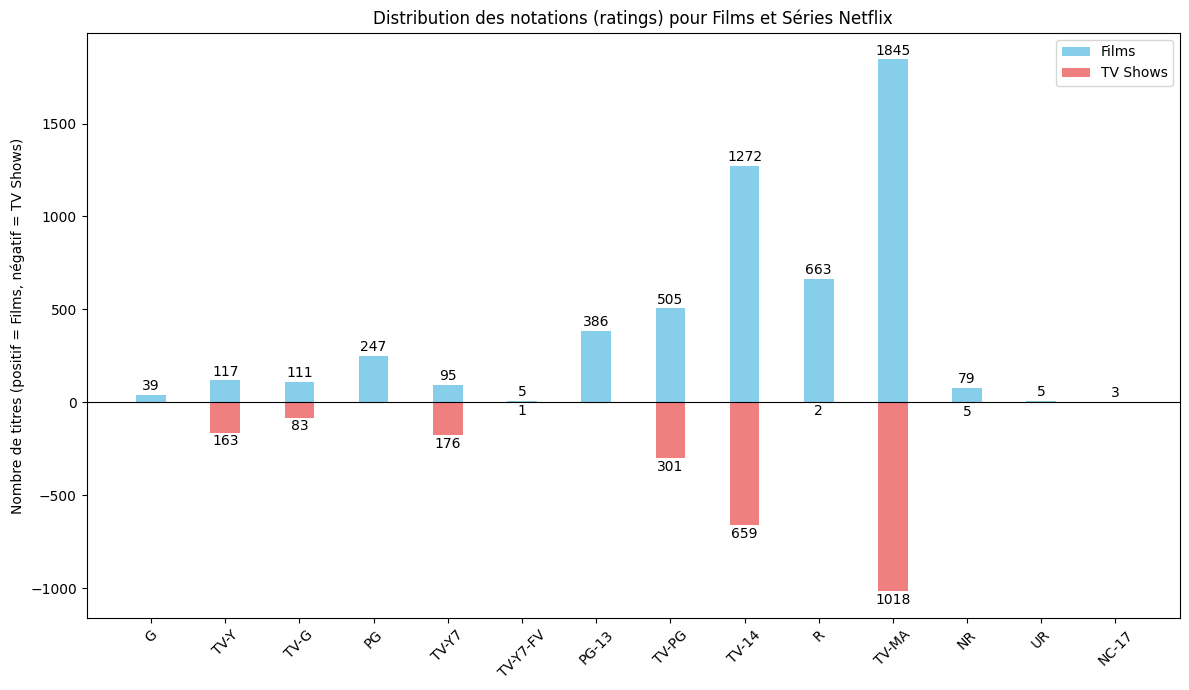

In [54]:
rating_counts = df.groupby(['type', 'rating']).size().reset_index(name='count')

# 2. Pivot pour faciliter la visualisation
rating_pivot = rating_counts.pivot(index='rating', columns='type', values='count').fillna(0)

# 3. Trier les notations selon un ordre logique
rating_order = ['G', 'TV-Y', 'TV-G', 'PG', 'TV-Y7', 'TV-Y7-FV', 'PG-13', 'TV-PG', 'TV-14', 'R', 'TV-MA', 'NR', 'UR', 'NC-17']
rating_pivot = rating_pivot.reindex(rating_order).dropna(how='all')

# 4. Création du graphique
labels = rating_pivot.index.tolist()
x = range(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# Barres pour les films (positif)
bars_film = ax.bar(x, rating_pivot.get('Film', 0), width, label='Films', color='skyblue')

# Barres pour les TV Shows (négatif)
bars_tv = ax.bar(x, -rating_pivot.get('TV', 0), width, label='TV Shows', color='lightcoral')

# 5. Annotations
for bar in bars_film:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}', ha='center', va='bottom')

for bar in bars_tv:
    height = bar.get_height()
    if height < 0:
        ax.text(bar.get_x() + bar.get_width()/2, height - 10, f'{int(-height)}', ha='center', va='top')

# 6. Personnalisation
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Nombre de titres (positif = Films, négatif = TV Shows)")
ax.set_title("Distribution des notations (ratings) pour Films et Séries Netflix")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()

<details>
  <summary>
    Indice 🔑
  </summary>
  
  - Groupez vos données par type de contenu (films ou émissions de télévision) et par notation.
  - Triez les notations selon l'ordre que vous avez déterminé précédemment.
  - Affichez les films en positif et les émissions de télévision en négatif sur le même graphique pour une meilleure comparaison.
  - Assurez-vous d'ajouter des annotations pour chaque barre afin de rendre le graphique plus informatif.
  - Ajoutez un titre, des légendes, et tout autre élément nécessaire pour rendre votre graphique complet et compréhensible.
</details>


### Question 13

❓**Question 13 :** En utilisant Seaborn, illustrez l'évolution annuelle du nombre de films et d'émissions de télévision produits par les États-Unis et la France.

In [55]:
import seaborn as sns

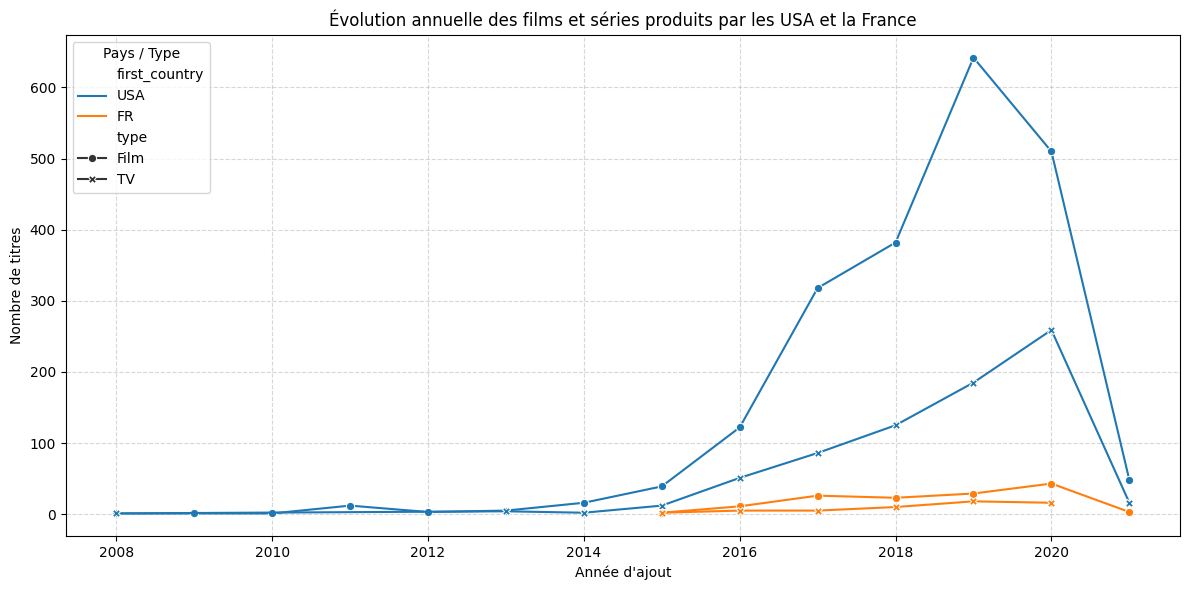

In [56]:
selected_countries = ['USA', 'FR']
df_sub = df[df['first_country'].isin(selected_countries)]

# 2. Supprimer les lignes avec années manquantes
df_sub = df_sub.dropna(subset=['year_added'])

# 3. Grouper par année, pays et type
grouped = df_sub.groupby(['year_added', 'first_country', 'type']).size().reset_index(name='count')

# 4. Visualisation avec Seaborn
plt.figure(figsize=(12,6))
sns.lineplot(data=grouped, x='year_added', y='count', hue='first_country', style='type', markers=True, dashes=False)

# 5. Customisation
plt.title("Évolution annuelle des films et séries produits par les USA et la France")
plt.xlabel("Année d'ajout")
plt.ylabel("Nombre de titres")
plt.legend(title="Pays / Type", loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<details>
  <summary>
    Indice 🔑
  </summary>

  - Créez un sous-ensemble de données qui ne contient que les entrées des États-Unis et de la France.
  - Groupez vos données par année, par pays et par type de contenu.
  - Utilisez un graphique linéaire pour montrer comment le nombre de titres a évolué au fil du temps pour chaque pays.
  - Assurez-vous d'ajouter des titres, des légendes et des annotations pour rendre votre graphique clair.
</details>

### Question 14

❓ **Question 14 :** En utilisant Bokeh, illustrez l'évolution cumulative de la quantité de Films et TV Shows ajoutés chaque mois sur Netflix.

💡 Un graphique en aires cumulatives est utile pour montrer comment une quantité augmente au fil du temps. Ici, il sera intéressant d'observer les mois pendant lesquels Netflix ajoute le plus de contenu.

In [70]:
from bokeh.io import output_notebook
output_notebook()


Loading BokehJS ...

In [75]:
month_order = ['January',
 'February',
 'March',
 'April',
 'May',
 'June',
 'July',
 'August',
 'September',
 'October',
 'November',
 'December']

df['month_name_added'] = pd.Categorical(df['month_name_added'], categories=month_order, ordered=True)

In [79]:
df_clean = df.dropna(subset=['month_name_added', 'type'])

# Grouper par mois et type
monthly_counts = df_clean.groupby(['month_name_added', 'type'], observed=True).size().unstack(fill_value=0)

# Réindexer pour s'assurer que tous les mois sont présents
monthly_counts = monthly_counts.reindex(month_order, fill_value=0)

# Calcul cumulatif
monthly_cumsum = monthly_counts.cumsum()

# Création du ColumnDataSource
source = ColumnDataSource(data={
    'month': month_order,
    'Film': monthly_cumsum['Film'] if 'Film' in monthly_cumsum else [0]*12,
    'TV': monthly_cumsum['TV'] if 'TV' in monthly_cumsum else [0]*12
})

# Création du graphique Bokeh
p = figure(x_range=month_order, height=400, title="Évolution cumulative des ajouts mensuels sur Netflix")

# Aires cumulées
p.varea(x='month', y1=0, y2='Film', source=source, fill_color="skyblue", legend_label='Films')
p.varea(x='month', y1='Film', y2='TV', source=source, fill_color="orange", legend_label='TV Shows')

# Personnalisation
p.xaxis.axis_label = "Mois"
p.yaxis.axis_label = "Nombre cumulé de titres"
p.legend.location = "top_left"
p.add_tools(HoverTool(tooltips=[("Mois", "@month"), ("Films", "@Film"), ("TV Shows", "@TV")]))

show(p)

<details>
  <summary>
    Indice 🔑
  </summary>

  - Groupez vos données par mois et par type de contenu pour obtenir une somme cumulative.
  - Tracez un graphique en aires pour montrer cette évolution cumulative.
  - Assurez-vous d'ajouter des titres, des légendes et des annotations pour rendre votre graphique explicite.
</details>


### Question 15

L'une des particularités de Netflix est sa capacité à fournir du contenu adapté à différentes tranches d'âge, de la programmation pour enfants aux films et séries destinés aux adultes. Ces catégories d'âge varient selon les normes de classification de chaque pays. Il serait intéressant de comprendre comment ces catégories d'âge cible sont distribuées parmi les contenus Netflix des principaux pays qui produisent ces contenus.

❓**Question 15 :** Créer une représentation visuelle (heatmap) pour illustrer la proportion de chaque catégorie d'âge cible par rapport au total des contenus Netflix pour les dix pays les plus représentés dans notre base de données.

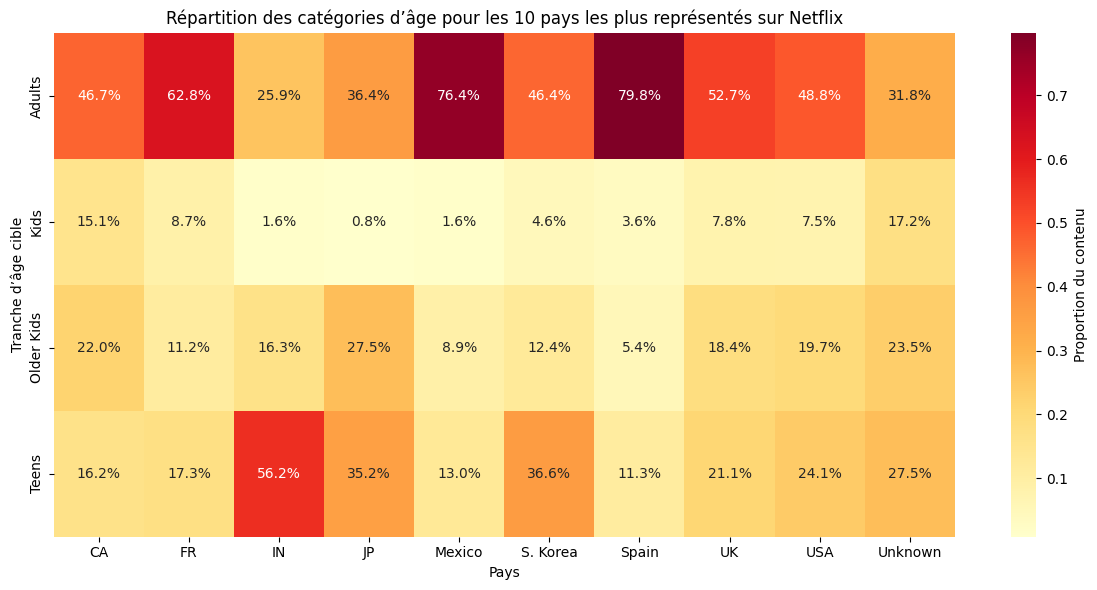

In [80]:
top_countries = df['first_country'].value_counts().head(10).index.tolist()

# 2. Filtrer les données pour ces pays
df_top = df[df['first_country'].isin(top_countries)]

# 3. Grouper par pays et tranche d’âge
grouped = df_top.groupby(['target_ages', 'first_country']).size().reset_index(name='count')

# 4. Créer tableau croisé (pivot) : target_ages en lignes, pays en colonnes
pivot = grouped.pivot(index='target_ages', columns='first_country', values='count').fillna(0)

# 5. Normaliser par colonne (proportion par pays)
pivot_prop = pivot.div(pivot.sum(axis=0), axis=1)

# 6. Affichage de la heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot_prop, annot=True, fmt=".1%", cmap="YlOrRd", cbar_kws={'label': 'Proportion du contenu'})
plt.title("Répartition des catégories d’âge pour les 10 pays les plus représentés sur Netflix")
plt.xlabel("Pays")
plt.ylabel("Tranche d’âge cible")
plt.tight_layout()
plt.show()

<details>
  <summary>
    Indice 🔑
  </summary>

  - Identifiez d'abord les 10 pays qui ont le plus grand nombre de contenus sur Netflix dans la base de données.
  - Pour ces 10 pays, calculez la distribution des catégories d'âge cible de leur contenu.
  - Créez une "heatmap" (carte de chaleur) pour visualiser ces distributions. Sur cette carte, les pays seront représentés en colonnes, les catégories d'âge en lignes, et les couleurs indiqueront la proportion de chaque catégorie d'âge pour chaque pays.
</details>


### Question 16

Netflix propose une variété de genres allant des drames aux documentaires, en passant par les thrillers et les comédies. Comprendre comment ces genres sont distribués dans différents pays peut nous donner un aperçu des préférences culturelles et des stratégies de contenu de Netflix pour ces marchés.

❓**Question 16 :** Analyser les cinq principaux genres de contenus pour chaque pays parmi les dix pays les plus représentés dans notre base de données. Ceci permettra de voir quels genres sont les plus populaires dans chaque pays.

In [81]:

# 1. Identifier les 10 pays avec le plus de contenus
top_countries = df['first_country'].value_counts().head(10).index.tolist()

# 2. Extraire les genres (sous forme de liste)
df['genre_list'] = df['listed_in'].str.split(', ').apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])

# 3. Initialiser un dict pour stocker les top genres par pays
country_genres = {}

# 4. Parcourir les 10 pays et compter les genres
for country in top_countries:
    genres = df[df['first_country'] == country]['genre_list']
    flat_genres = [genre for sublist in genres for genre in sublist]
    top5 = Counter(flat_genres).most_common(5)
    for genre, count in top5:
        country_genres.setdefault(country, []).append((genre, count))

# 5. Convertir en DataFrame pour visualisation
data = []
for country, genre_data in country_genres.items():
    for genre, count in genre_data:
        data.append({'country': country, 'genre': genre, 'count': count})

df_top_genres = pd.DataFrame(data)


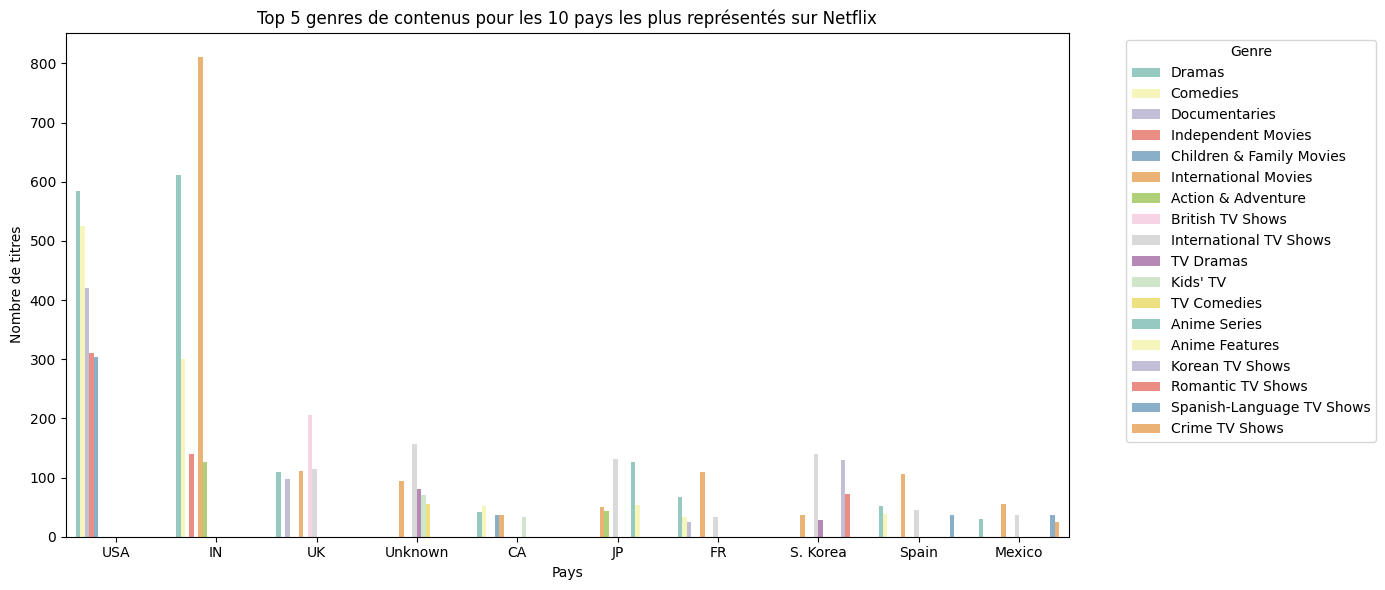

In [82]:
plt.figure(figsize=(14,6))
sns.barplot(data=df_top_genres, x='country', y='count', hue='genre', palette='Set3')

plt.title("Top 5 genres de contenus pour les 10 pays les plus représentés sur Netflix")
plt.xlabel("Pays")
plt.ylabel("Nombre de titres")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<details>
  <summary>
    Indice 🔑
  </summary>

  - Identifiez d'abord les 10 pays qui ont le plus grand nombre de contenus sur Netflix dans la base de données.
  - Pour chaque pays, identifiez les cinq principaux genres (par exemple, drame, comédie, thriller, etc.) les plus couramment associés aux contenus de ce pays.
  - Visualisez ces informations à l'aide d'un diagramme à barres empilées ou d'un treemap, où chaque pays est représenté par une section, subdivisée en genres.
</details>

### Question 17

❓ **Question 17 :** Imaginez que vous travaillez pour une société de production souhaitant lancer une nouvelle série sur une plateforme de streaming similaire à Netflix.

En vous basant sur l'analyse des données de Netflix effectuée dans ce TP, quelles recommandations stratégiques pourriez-vous faire concernant le genre, la cible d'âge, et le pays de lancement de la série pour maximiser son succès ? Justifiez vos choix en vous appuyant sur des données et des visualisations spécifiques explorées dans ce TP.

In [ ]:
Recommandation 

Il faudrait cibler davantage Les teens (adolescents) et adultes car ils représentent la majorité des contenus sur Netflix.

L’Inde est en pleine expansion, avec une forte proportion de contenus récents et les séries locales avec des thèmes universels 
(relations, famille, société) marchent bien dans ces pays.